In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing import TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END

In [4]:
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [5]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [6]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000018814828950>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001881497DD90>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [20]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    score: int

In [21]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']
    
    #call llm get outline
    prompt = f"generate a detailed outline for a blog on the topic - {title}"
    outline = llm.invoke(prompt).content
    
    #update state 
    state['outline'] = outline
    
    return state

In [22]:
def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    
    prompt = f"write a detailed blog on the title - {title} using the following outline \n {outline}"
    
    content = llm.invoke(prompt).content
    
    state['content'] = content
    
    return state

In [23]:
def evaluate_blog(state: BlogState) -> BlogState:
    outline = state['outline']
    content = state['content']
    
    #call llm and made it evakuate the blog
    prompt = f"Based on the given outine \n {outline} rate my blog \n {content} on score of 1 to 10"
    
    score = llm.invoke(prompt).content
    
    state['score'] = score
    
    return state

In [24]:
#create graph
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)

# add nodes
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

#compile graph
workflow = graph.compile()

In [25]:
intial_state = {'title': 'Rise of EV vehicles in India'}

final_state = workflow.invoke(intial_state)

In [26]:
print(final_state['score'])

I would rate your blog a score of 9 out of 10. Here's a breakdown of the strengths and weaknesses of your blog:

**Strengths:**

1. **Comprehensive outline**: Your blog follows a clear and comprehensive outline, covering all the necessary aspects of the topic, including the current state of EVs in India, government initiatives, technological advancements, growing consumer awareness, opportunities and challenges, and future outlook.
2. **Well-structured content**: Your blog is well-structured, with each section flowing logically into the next, making it easy to follow and understand.
3. **Clear and concise writing**: Your writing is clear, concise, and free of jargon, making it accessible to a wide range of readers.
4. **Use of statistics and data**: You have included relevant statistics and data to support your arguments, making your blog more credible and informative.
5. **Good use of transitions**: You have used transitional phrases and sentences to connect your ideas and paragraphs,

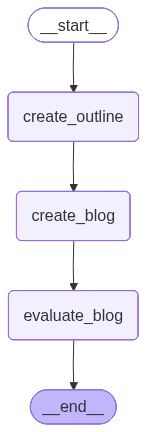

In [27]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())